## Gradient Descent optimization for linear regression

Iteration 0: Cost = 2968.4809
Iteration 100: Cost = 1149.7883
Iteration 200: Cost = 910.5938
Iteration 300: Cost = 867.8430
Iteration 400: Cost = 849.7360
Iteration 500: Cost = 834.9282
Iteration 600: Cost = 820.7635
Iteration 700: Cost = 806.9075
Iteration 800: Cost = 793.3142
Iteration 900: Cost = 779.9737
Final parameters (theta): [55.56031749  3.78440011 21.0398273  10.34014553 41.75750735]


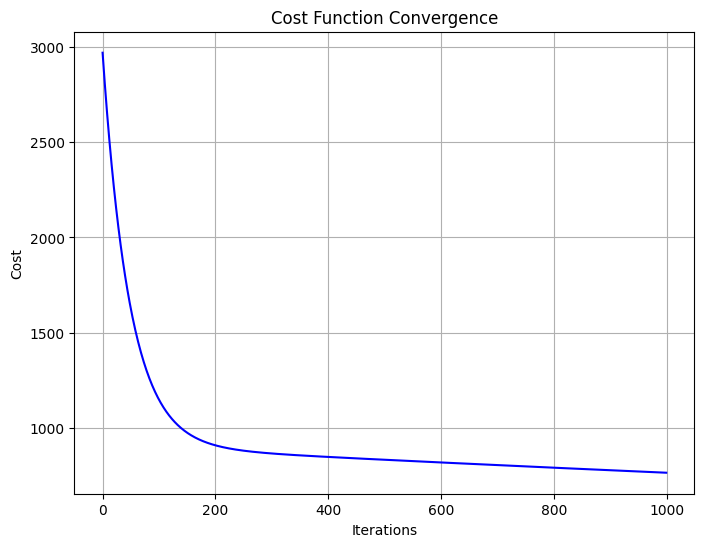


Gradient Descent Linear Regression Results:
Mean Squared Error: 1336.84
R2 Score: 0.19


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Data Cleaning and Preparation
data = data.dropna(subset=['Country'])  # Remove rows with missing 'Country'

# Encode AQI Category as numeric
category_map = {
    'Good': 1, 'Moderate': 2, 'Unhealthy for Sensitive Groups': 3,
    'Unhealthy': 4, 'Very Unhealthy': 5, 'Hazardous': 6
}
data['AQI Category Numeric'] = data['AQI Category'].map(category_map)

# Select features and target
features = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = data[features]
y = data['AQI Value']

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Add a bias column to X for the intercept term
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert training data to NumPy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

# Gradient Descent Function
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape  # Number of samples and features
    theta = np.zeros(n)  # Initialize coefficients (weights)
    cost_history = []  # Store cost function values

    for i in range(iterations):
        # Calculate predictions
        predictions = np.dot(X, theta)

        # Calculate errors
        errors = predictions - y

        # Compute gradients
        gradients = (1 / m) * np.dot(X.T, errors)

        # Update parameters
        theta -= learning_rate * gradients

        # Calculate cost (Mean Squared Error)
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)

        # Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return theta, cost_history

# Run Gradient Descent
learning_rate = 0.01
iterations = 1000
theta, cost_history = gradient_descent(X_train, y_train, learning_rate, iterations)

# Print final parameters
print("Final parameters (theta):", theta)

# Plot Cost Function over Iterations
plt.figure(figsize=(8, 6))
plt.plot(range(iterations), cost_history, color='blue')
plt.title('Cost Function Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid()
plt.show()

# Predictions on Test Set
y_pred_gd = np.dot(X_test, theta)

# Evaluate Model
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\nGradient Descent Linear Regression Results:")
print(f"Mean Squared Error: {mse_gd:.2f}")
print(f"R2 Score: {r2_gd:.2f}")


Classification Metrics:
Accuracy: 0.99
Precision: 0.99
F1 Score: 0.99

Regression Metrics:
Mean Squared Error (MSE): 0.01
Mean Absolute Error (MAE): 0.01
R² Score: 0.98

Confusion Matrix:
[[1568    1    0    0    0    0]
 [   5 1426    0    0    0    0]
 [   0   15  129    3    0    0]
 [   0    0    1  157    0    0]
 [   0    0    0   12   13    0]
 [   0    0    0    0    2    7]]

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1569
           2       0.99      1.00      0.99      1431
           3       0.99      0.88      0.93       147
           4       0.91      0.99      0.95       158
           5       0.87      0.52      0.65        25
           6       1.00      0.78      0.88         9

    accuracy                           0.99      3339
   macro avg       0.96      0.86      0.90      3339
weighted avg       0.99      0.99      0.99      3339



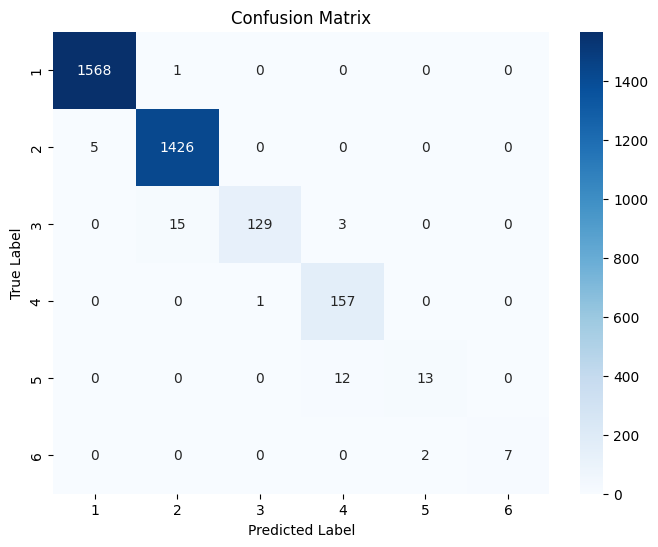

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y for training (assuming 4 features are available for classification)
X = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
y = data['AQI Category Numeric']

# Split the data into training and test sets
X_train_2f, X_test_2f, y_train_2f, y_test_2f = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an MLP Classifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(50, 30), activation="relu", solver="adam", max_iter=500, random_state=42
)
mlp_classifier.fit(X_train_2f, y_train_2f)

# Predict on the test set
y_pred_2f = mlp_classifier.predict(X_test_2f)

# Classification Metrics
accuracy = accuracy_score(y_test_2f, y_pred_2f)
precision = precision_score(y_test_2f, y_pred_2f, average="weighted")
f1 = f1_score(y_test_2f, y_pred_2f, average="weighted")

print("Classification Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F1 Score: {f1:.2f}")

# Regression Metrics
mse = mean_squared_error(y_test_2f, y_pred_2f)
mae = mean_absolute_error(y_test_2f, y_pred_2f)
r2 = r2_score(y_test_2f, y_pred_2f)

print("\nRegression Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Confusion Matrix and Report
conf_matrix = confusion_matrix(y_test_2f, y_pred_2f)
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test_2f, y_pred_2f))

# Visualization of Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Linear Regression:
MSE: 42.307358435933004
MAE: 4.176590736069108
R2: 0.9744908345378135

Random Forest Regression:
MSE: 2.5933745732255167
MAE: 0.08944893680742742
R2: 0.9984363282525895

Classification Metrics:
Accuracy: 0.9991015274034142
Precision: 0.9991182691288164
F1 Score: 0.9991006448596499

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      1569
           2       1.00      1.00      1.00      1431
           3       1.00      0.99      0.99       147
           4       0.98      1.00      0.99       158
           5       1.00      0.96      0.98        25
           6       1.00      1.00      1.00         9

    accuracy                           1.00      3339
   macro avg       1.00      0.99      0.99      3339
weighted avg       1.00      1.00      1.00      3339



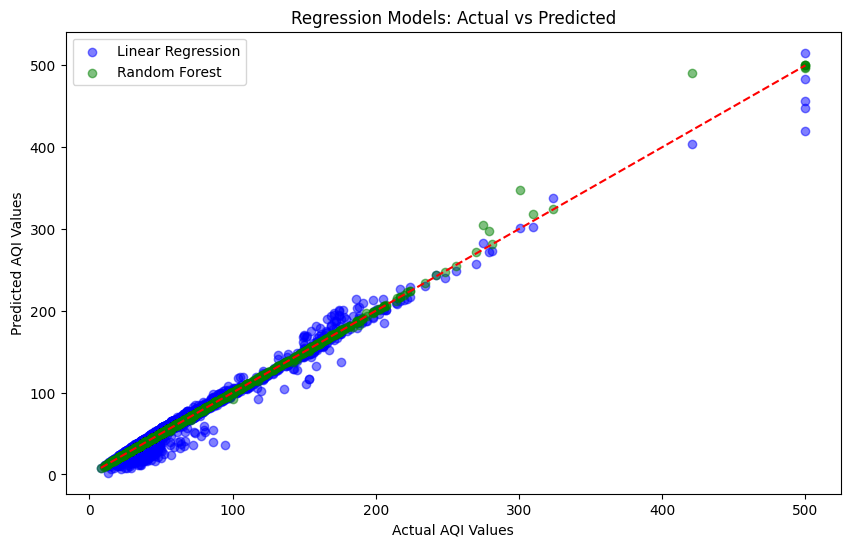

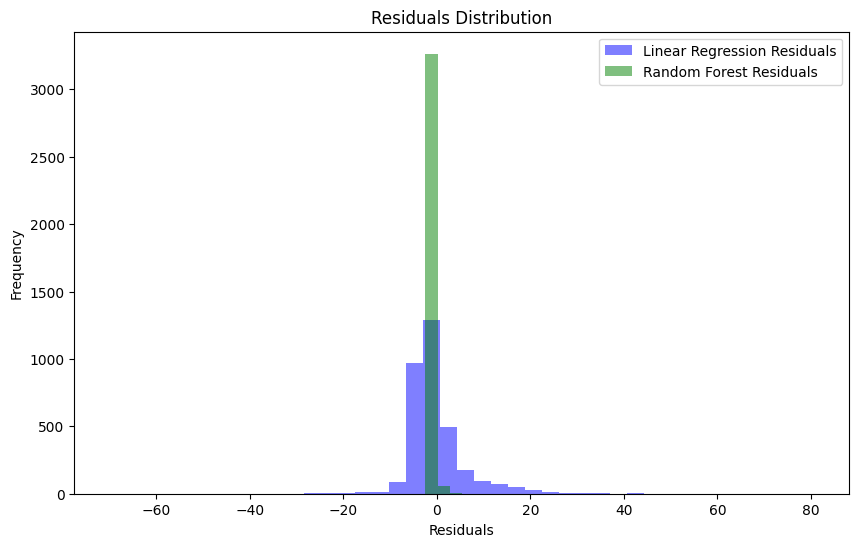

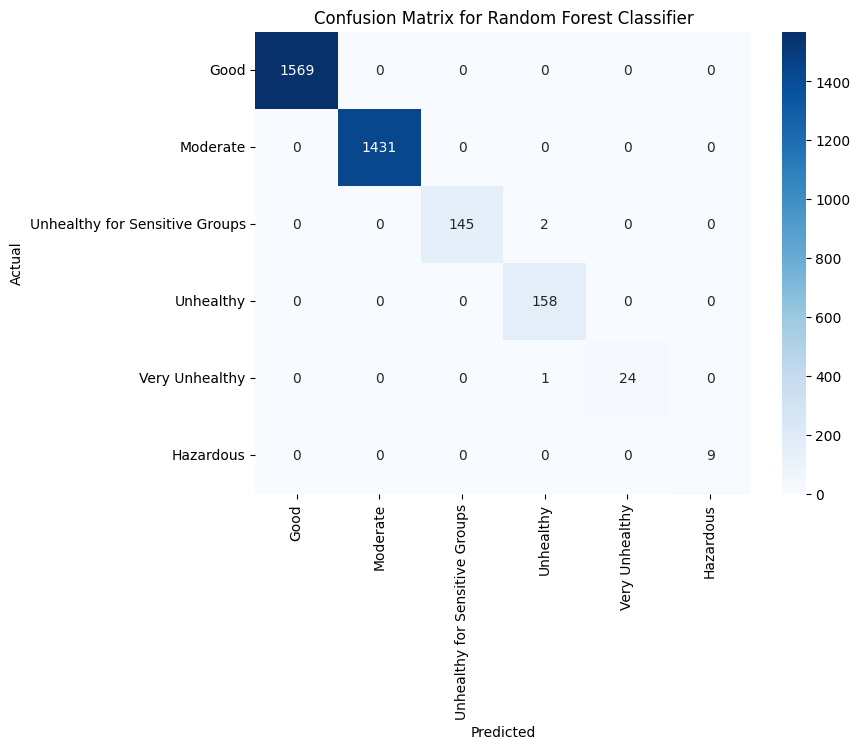

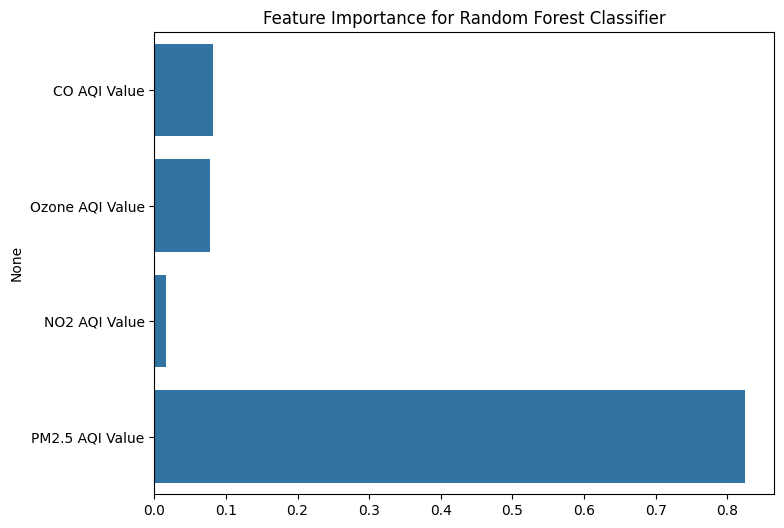

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load dataset
file_path = 'Data\Real-Data\AQI and Lat Long of Countries.csv'  # Update with your file path
data = pd.read_csv(file_path)

# Drop missing values
data = data.dropna(subset=['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value'])

# Encode AQI Category as numeric
category_map = {
    'Good': 1, 'Moderate': 2, 'Unhealthy for Sensitive Groups': 3,
    'Unhealthy': 4, 'Very Unhealthy': 5, 'Hazardous': 6
}
data['AQI Category Numeric'] = data['AQI Category'].map(category_map)

# Select features and targets
X = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
y_regression = data['AQI Value']
y_classification = data['AQI Category Numeric']

# Split data
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)
_, _, y_train_class, y_test_class = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Regression Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)
y_pred_lr = lr_model.predict(X_test)

rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train, y_train_reg)
y_pred_rf = rf_reg_model.predict(X_test)

# Classification Model
rf_class_model = RandomForestClassifier(random_state=42)
rf_class_model.fit(X_train, y_train_class)
y_pred_class = rf_class_model.predict(X_test)

# Regression Metrics
print("Linear Regression:")
print("MSE:", mean_squared_error(y_test_reg, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr))
print("R2:", r2_score(y_test_reg, y_pred_lr))

print("\nRandom Forest Regression:")
print("MSE:", mean_squared_error(y_test_reg, y_pred_rf))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("R2:", r2_score(y_test_reg, y_pred_rf))

# Classification Metrics
print("\nClassification Metrics:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class, average='weighted'))
print("F1 Score:", f1_score(y_test_class, y_pred_class, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Visualization for Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_lr, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(y_test_reg, y_pred_rf, color='green', alpha=0.5, label='Random Forest')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--')
plt.xlabel("Actual AQI Values")
plt.ylabel("Predicted AQI Values")
plt.title("Regression Models: Actual vs Predicted")
plt.legend()
plt.show()

# Residual Plot
plt.figure(figsize=(10, 6))
residuals_lr = y_test_reg - y_pred_lr
residuals_rf = y_test_reg - y_pred_rf
plt.hist(residuals_lr, bins=30, alpha=0.5, color='blue', label='Linear Regression Residuals')
plt.hist(residuals_rf, bins=30, alpha=0.5, color='green', label='Random Forest Residuals')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.legend()
plt.show()

# Confusion Matrix for Classification
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=category_map.keys(), yticklabels=category_map.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

# Feature Importance for Classification
feature_importance = rf_class_model.feature_importances_
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance, y=X.columns)
plt.title("Feature Importance for Random Forest Classifier")
plt.show()
